# Project Description:

The purpose of this project is to implement a neural network that performs the translation of mathematical formulae from traditional **infix notation**—where the operator appears between two operands—to **postfix** (also known as Reverse Polish Notation), where the operator follows the operands.

Infix notation is the most commonly used in human-readable mathematics (e.g., a + b), but it is inherently ambiguous without additional syntactic aids such as parentheses or operator precedence rules. This ambiguity arises because different parse trees can correspond to the same expression depending on how operations are grouped.

In contrast, postfix notation eliminates the need for parentheses entirely. The order of operations is explicitly encoded by the position of the operators relative to the operands, making it more suitable for stack-based evaluation and easier to parse programmatically.

**Example:**

Consider the ambiguous infix expression:
a + b * c

This expression can be parsed in at least two different ways:

Interpretation (Infix):	(a + b) * c	   
Equivalent Postfix: ab+c*

Interpretation (Infix):	a + (b * c)	          
Equivalent Postfix: abc*+


This project aims to learn such disambiguations and generate the correct postfix form from a given infix expression using a data-driven approach based on neural networks.

To simplify the task and control the complexity of expressions, we restrict our dataset to formulae with a maximum syntactic depth of 4. This means that the abstract syntax trees representing these expressions will have at most three levels, ensuring that the neural network operates on a bounded and manageable set of possible structures.

In [3]:
import numpy as np
import random
import string
import tensorflow as tf
from tensorflow.keras import layers, models
from tqdm import tqdm
print(tf.__version__)
print(tf.keras.__version__)

2.19.0
3.10.0


We build formulae using 6 identifiers a,b,c,d,e,f and 4 binary operators +,-,*,/.
For simplicity we do not take advantage of precedence or associativity rules for infix notation, and suppose that all binary operations as always fully parenthesizes: (e1 op e2).

In [4]:
# -------------------- Constants --------------------
OPERATORS = ['+', '-', '*', '/']
IDENTIFIERS = list('abcdef')
SPECIAL_TOKENS = ['PAD', 'SOS', 'EOS']
SYMBOLS = ['(', ')', '+', '-', '*', '/']
VOCAB = SPECIAL_TOKENS + SYMBOLS + IDENTIFIERS + ['JUNK'] #may use junk in autoregressive generation

token_to_id = {tok: i for i, tok in enumerate(VOCAB)}
id_to_token = {i: tok for tok, i in token_to_id.items()}
VOCAB_SIZE = len(VOCAB)
PAD_ID = token_to_id['PAD']
EOS_ID = token_to_id['EOS']
SOS_ID = token_to_id['SOS']

MAX_DEPTH = 4
MAX_LEN = 4*2**MAX_DEPTH -2 #enough to fit expressions at given depth (+ EOS)

In [5]:
# -------------------- Expression Generation --------------------
def generate_infix_expression(max_depth):
    if max_depth == 0:
        return random.choice(IDENTIFIERS)
    elif random.random() < 0.25:
        return generate_infix_expression(max_depth - 1)
    else:
        left = generate_infix_expression(max_depth - 1)
        right = generate_infix_expression(max_depth - 1)
        op = random.choice(OPERATORS)
        return f'({left} {op} {right})'

def tokenize(expr):
    return [c for c in expr if c in token_to_id]

def infix_to_postfix(tokens):
    precedence = {'+': 1, '-': 1, '*': 2, '/': 2}
    output, stack = [], []
    for token in tokens:
        if token in IDENTIFIERS:
            output.append(token)
        elif token in OPERATORS:
            while stack and stack[-1] in OPERATORS and precedence[stack[-1]] >= precedence[token]:
                output.append(stack.pop())
            stack.append(token)
        elif token == '(':
            stack.append(token)
        elif token == ')':
            while stack and stack[-1] != '(':
                output.append(stack.pop())
            stack.pop()
    while stack:
        output.append(stack.pop())
    return output

def encode(tokens, max_len=MAX_LEN):
    ids = [token_to_id[t] for t in tokens] + [EOS_ID]
    return ids + [PAD_ID] * (max_len - len(ids))

def decode_sequence(token_ids, id_to_token, pad_token='PAD', eos_token='EOS'):
    """
    Converts a list of token IDs into a readable string by decoding tokens.
    Stops at the first EOS token if present, and ignores PAD tokens.
    """
    tokens = []
    for token_id in token_ids:
        token = id_to_token.get(token_id, '?')
        if token == eos_token:
            break
        if token != pad_token:
            tokens.append(token)
    return ' '.join(tokens)

def generate_dataset(n,max_depth=MAX_DEPTH):
    X, Y = [], []
    for _ in range(n):
        expr = generate_infix_expression(MAX_DEPTH)
        #expr = expr_gen.generate(max_depth=max_dthep)
        infix = tokenize(expr)
        postfix = infix_to_postfix(infix)
        X.append(encode(infix))
        Y.append(encode(postfix))
    return np.array(X), np.array(Y)

#you might use the shift function for teacher-forcing
def shift_right(seqs):
    shifted = np.zeros_like(seqs)
    shifted[:, 1:] = seqs[:, :-1]
    shifted[:, 0] = SOS_ID
    return shifted

Let us define a simple dataset, and inspect a few samples. You can use a larger dataset, if you want, or directly use the generator.

In [6]:
X_train, Y_train = generate_dataset(10000)
decoder_input_train = shift_right(Y_train)

# Dataset
X_val, Y_val = generate_dataset(1000)
decoder_input_val = shift_right(Y_val)

In [7]:
i =  np.random.randint(10000)
print(i)
print("infix : ",decode_sequence(X_train[i],id_to_token))
print("posfix notation: ",decode_sequence(Y_train[i],id_to_token))
print("teacher forcing : ", decode_sequence(decoder_input_train[i],id_to_token))

1574
infix :  ( ( ( e - d ) / ( e * d ) ) / ( ( d - a ) - ( c / b ) ) )
posfix notation:  e d - e d * / d a - c b / - /
teacher forcing :  SOS e d - e d * / d a - c b / - /


# Constraints
* You may use any architecture (decoder-only, encoder-decoder, or other).

* The maximum number of parameters is 2 million.

* Beam search is not allowed.

* You may adapt the formula generator to your needs, but preserve its core logic—especially the frequency distribution of formulas by depth, as it may significantly influence model performance.

* You may train your model using a pre-generated fixed dataset (e.g., an array) or directly use an on-the-fly generator.




# Evaluation

We shall evaluate a generated item y_pred using "prefix accuracy", the lenght of
the initial prefix of y_pred matching the ground true y_true. This will be divided by the maximum length of y_true and y_pred (up to EOS), so that a perfect match has score 1.

* It's more informative than exact match (which is often 0)

* It’s tighter than edit distance: focuses on generation flow

* Captures where the model starts to make errors



In [8]:
def prefix_accuracy_single(y_true, y_pred, id_to_token, eos_id=EOS_ID, verbose=False, print_n_tokens=False):
    t_str = decode_sequence(y_true, id_to_token).split(' EOS')[0]
    p_str = decode_sequence(y_pred, id_to_token).split(' EOS')[0]
    t_tokens = t_str.strip().split()
    p_tokens = p_str.strip().split()
    if print_n_tokens:
        print(len(p_tokens))
    max_len = max(len(t_tokens), len(p_tokens))
    n = min(len(t_tokens), len(p_tokens))
    match_len = 0
    while match_len < n and t_tokens[match_len] == p_tokens[match_len]:
        match_len += 1
    score = match_len / max_len if max_len>0 else 0
    if verbose:
        print("TARGET :", ' '.join(t_tokens))
        print("PREDICT:", ' '.join(p_tokens))
        print(f"PREFIX MATCH: {match_len}/{len(t_tokens)} → {score:.2f}")

    return score

In [9]:
#example
i = np.random.randint(10000)
expected = np.copy(Y_train[i])
generated = np.copy(Y_train[i])
expr_len = np.where(generated==EOS_ID)[0][0]
j = np.random.randint(expr_len)
generated[j] = EOS_ID #making shorter
prefix_accuracy_single(expected,generated,id_to_token,verbose=True)

TARGET : b d / e c / * a d * a - / c a - b b * / +
PREDICT: b d / e c / * a d * a - / c a - b b
PREFIX MATCH: 18/21 → 0.86


0.8571428571428571

For the exam, evaluate you model on a test set of 30 expressions. Repeat this evaluation 10 times, and return the mean and std for this rounds.

In [10]:
def test(no=30,rounds=10):
  rscores =[]
  for i in range(rounds):
    print("round=",i)
    X_test, Y_test = generate_dataset(no)
    scores = []
    for j in range(no):
        encoder_input=X_test[j]
        try:
            generated = autoregressive_decode(model, encoder_input)[1:] #remove SOS
        except NameError:
            print('Error: autoregressive_decode function still have to be defined!\n       (0, 0) is returned')
            return 0,0
        scores.append(prefix_accuracy_single(Y_test[j], generated, id_to_token))
    rscores.append(np.mean(scores))
  return np.mean(rscores),np.std(rscores)

res, std = test(30,10)
print("score=",res,"std=",std)

round= 0
Error: autoregressive_decode function still have to be defined!
       (0, 0) is returned
score= 0 std= 0


Be sure to evalutate the generator: your model may only take as input the expression in infix format and return its translation to postifix.

If you are usuing an encoder-decoder model, generation must be done autoregressively.

# What to deliver

As usual you are supposed to deliver a single notebook witten in Keras. You are auhtorized to use Keras3 with pytorch as backend if you prefer.

Do no upload a zip file: the submission will be rejected.

The python notebook should have a clear documentation of the training phase, possibly with its history.

Please provide the network parameters by means of gdown.

# Model development
In this section the model we be developed by the student (Martino Michelotti). Starting by defining the models architecture and following with its training

In [11]:
from tensorflow.keras.layers import Input, Bidirectional, LSTM, Embedding, Concatenate, AdditiveAttention, Dense

## Model architecture
For the model architecture I opted for a bidirectional-LSTM Encoder followed by an unidirectional LSTM Decoder with attention. This permits the network to capture contextual informations in both directions while encoding, focusing on the whole structure of the sequence; useful in this case for capturing non-local structures like parentheses. The Decoder uses an attention mechanism to focus on the relevant tokens of the sequence while autoregressively generating the output tokens.

### Encoder

In [12]:
def build_encoder(vocab_size, emb_dim, enc_units):
    encoder_inputs =Input(shape=(None,), name='encoder_inputs')

    x = Embedding(vocab_size, emb_dim, mask_zero=False)(encoder_inputs)

    encoder_outputs, forward_h, forward_c, backward_h, backward_c = Bidirectional(
        LSTM(enc_units, return_sequences=True, return_state=True)
    )(x)

    state_h = Concatenate()([forward_h, backward_h])
    state_c = Concatenate()([forward_c, backward_c])

    return encoder_inputs, encoder_outputs, state_h, state_c

### Decoder


In [13]:
def build_decoder(vocab_size, emb_dim, dec_units, encoder_outputs, enc_state_h, enc_state_c):
    decoder_inputs = Input(shape=(None,), name='decoder_inputs')

    x = Embedding(vocab_size, emb_dim, mask_zero=False)(decoder_inputs)

    decoder_lstm = LSTM(dec_units*2, return_sequences=True, return_state=True)

    decoder_outputs, _, _ = decoder_lstm(x, initial_state=[enc_state_h, enc_state_c])

    attention = AdditiveAttention()
    context = attention([decoder_outputs, encoder_outputs])

    concat = Concatenate()([decoder_outputs, context])

    outputs = Dense(vocab_size, activation='softmax')(concat)

    return decoder_inputs, outputs

### Building the model

In [14]:
def build_model(vocab_size, emb_dim=64, units=64):
    enc_inputs, enc_outputs, enc_h, enc_c = build_encoder(
        vocab_size, emb_dim, units
    )

    dec_inputs, dec_outputs = build_decoder(
        vocab_size, emb_dim, units, enc_outputs, enc_h, enc_c
    )

    model = models.Model(
        inputs=[enc_inputs, dec_inputs],
        outputs=dec_outputs
    )

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [15]:
model = build_model(vocab_size=VOCAB_SIZE)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, None, 64)  │      1,024 │ encoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs      │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ [(None, None,     │     66,048 │ embedding[0][0]   │
│ (Bidirectional)     │ 128), (None, 64), │            │                   │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, None, 64)  │      1,024 │ decoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128)       │          0 │ bidirectional[0]… │
│ (Concatenate)       │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128)       │          0 │ bidirectional[0]… │
│ (Concatenate)       │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, None,     │     98,816 │ embedding_1[0][0… │
│                     │ 128), (None,      │            │ concatenate[0][0… │
│                     │ 128), (None,      │            │ concatenate_1[0]… │
│                     │ 128)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ additive_attention  │ (None, None, 128) │        128 │ lstm_1[0][0],     │
│ (AdditiveAttention) │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, None, 256) │          0 │ lstm_1[0][0],     │
│ (Concatenate)       │                   │            │ additive_attenti… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, None, 16)  │      4,112 │ concatenate_2[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 171,152 (668.56 KB)

 Trainable params: 171,152 (668.56 KB)

 Non-trainable params: 0 (0.00 B)

## Training

In [17]:
# setting random seed
seed=42

random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

In [18]:
from tensorflow.keras.callbacks import EarlyStopping

#implementing EarlyStopping to ensure the best weights found during training
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [19]:
do_train=True

In [20]:
epochs = 20
batch_size = 64

if do_train:
  history = model.fit(
      [X_train, decoder_input_train],
      Y_train,
      batch_size=64,
      epochs=epochs,
      validation_data=([X_val, decoder_input_val], Y_val),
      callbacks=[early_stop]
  )

  model.save_weights('infix_to_postfix.weights.h5')



Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - accuracy: 0.6981 - loss: 1.0146 - val_accuracy: 0.7700 - val_loss: 0.5730
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.7818 - loss: 0.5516 - val_accuracy: 0.8150 - val_loss: 0.4796
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.8194 - loss: 0.4667 - val_accuracy: 0.8389 - val_loss: 0.4194
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.8475 - loss: 0.3991 - val_accuracy: 0.8831 - val_loss: 0.3240
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.8924 - loss: 0.3042 - val_accuracy: 0.9284 - val_loss: 0.2216
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9392 - loss: 0.1996 - val_accuracy: 0.9638 - val_loss: 0.1344
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.9706 - loss: 0.1120 - val_accuracy: 0.9859 - val_loss: 0.0610
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.9883 - loss: 0.0527 - val_acc

### Training history plot

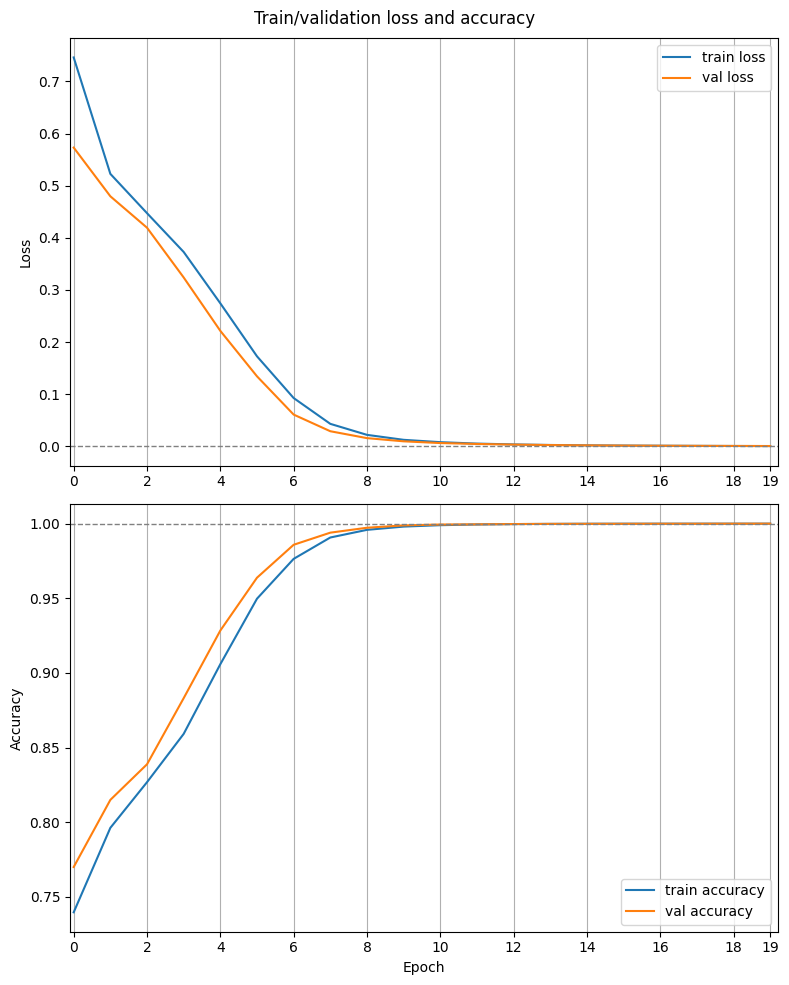

In [56]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(8, 10), tight_layout=True)

fig.subplots_adjust(hspace=0.1)

ticks= list(range(0,epochs, 2))
ticks.append(epochs-1)

ax1.plot(history.history['loss'], label='train loss')
ax1.plot(history.history['val_loss'], label='val loss')
ax1.set_ylabel('Loss')
ax1.set_xticks(ticks)
ax1.set_xlim(-0.1,19.2)
ax1.axhline(y=0, color='gray', linestyle='--', linewidth=1)
ax1.legend()

ax2.plot(history.history['accuracy'], label='train accuracy')
ax2.plot(history.history['val_accuracy'], label='val accuracy')
ax2.set_ylabel('Accuracy')
ax2.set_xticks(ticks)
ax2.set_xlim(-0.1,19.2)
ax2.axhline(y=1, color='gray', linestyle='--', linewidth=1)
ax2.legend()


ax1.grid(axis='x')  # Vertical grid lines only for ax1
ax2.grid(axis='x')  # Vertical grid lines only for ax2

plt.suptitle('Train/validation loss and accuracy')
plt.xlabel('Epoch')
plt.show()


Since we have a classical declarative function that computes the solution to our problem, I tried to get to 100% accuracy also with the DL model. Trying out a model with an higher embedding dimension I found out that it reached the goal in fewer epochs, but training was obviously slower. Therefore I decided to opt to a model with less parameters and training it for some more epochs, having a reduction in the later computational cost of inference.

## Testing

### Defining testing utils

In [22]:
def autoregressive_decode(model, encoder_input, max_len=MAX_LEN):
    # fixing the input shape as (1, MAX_LEN)
    encoder_input = np.array(encoder_input).reshape(1, -1)

    decoder_seq = [SOS_ID]

    for _ in range(max_len - 1):
        # Prepare decoder input tensor
        decoder_input = np.array(decoder_seq).reshape(1, -1)

        # Predict next token distribution
        preds = model.predict([encoder_input, decoder_input], verbose=0)

        # Get last timestep prediction
        next_token = np.argmax(preds[0, -1])
        decoder_seq.append(next_token)

        if next_token == EOS_ID:
            break

    return decoder_seq


In [23]:
# autoregressive_decode function sanity check
i = 0
decoded = autoregressive_decode(model, X_train[i])

print("Infix:   ", decode_sequence(X_train[i], id_to_token))
print("Target:  ", decode_sequence(Y_train[i], id_to_token))
print("Decoded: ", decode_sequence(decoded, id_to_token))

Infix:    ( ( ( f / ( d / d ) ) + ( f + f ) ) + ( ( c / a ) * ( ( c + d ) / c ) ) )
Target:   f d d / / f f + + c a / c d + c / * +
Decoded:  SOS f d d / / f f + + c a / c d + c / * +


In [24]:
# modified just to use tqdm library showing progressbar
def test(no=30,rounds=10):
  rscores =[]
  for i in range(rounds):
    print("round =",i)
    X_test, Y_test = generate_dataset(no)
    scores = []
    for j in tqdm(range(no)):
        encoder_input=X_test[j]
        try:
            generated = autoregressive_decode(model, encoder_input)[1:] #remove SOS
        except NameError:
            print('Error: autoregressive_decode function still have to be defined!\n       (0, 0) is returned')
            return 0,0
        scores.append(prefix_accuracy_single(Y_test[j], generated, id_to_token))
    rscores.append(np.mean(scores))
  return np.mean(rscores),np.std(rscores)


### Loading pre-trained weights
The trained network parameters are saved on Google drive, they can be downloaded using the command:

gdown https://drive.google.com/uc?id=wghts_fileID

In [28]:
wghts_fileID = '1Kr3ZmIn6DXgvaMesLfBJ4iNvRHFGCIOF'
!gdown  https://drive.google.com/uc?id={wghts_fileID}

model.load_weights('infix_to_postfix.weights.h5')

Downloading...
From: https://drive.google.com/uc?id=1Kr3ZmIn6DXgvaMesLfBJ4iNvRHFGCIOF
To: /content/infix_to_postfix.weights.h5
100% 2.11M/2.11M [00:00<00:00, 3.13MB/s]


### Testing loop

In [26]:
do_test = True

In [29]:
if do_test:
  res, std = test(30,10)

  print('\nRESULTS:\n')
  print("score=",res,"std=",std)

round = 0


100%|██████████| 30/30 [00:39<00:00,  1.33s/it]


round = 1


100%|██████████| 30/30 [00:35<00:00,  1.19s/it]


round = 2


...

round = 8


100%|██████████| 30/30 [00:39<00:00,  1.30s/it]


round = 9


100%|██████████| 30/30 [00:46<00:00,  1.53s/it]


RESULTS:

score= 1.0 std= 0.0


I got perfect results on the testing data.
This does not imply that this data-driven approach is the most suitable for addressing such a problem, which we know can be solved algorithmically, moreover with a lower consumption of computational resources.

